In [1]:
%matplotlib inline
import matplotlib
print('backend:', matplotlib.get_backend())

backend: inline


In [1]:
print(1)

1


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "blog" / "bv_annual.csv").exists() and (candidate / "blog" / "viirs_monthly.csv").exists():
            return candidate
    raise FileNotFoundError("Could not find the repository root from the current working directory")

root = find_repo_root(Path.cwd())
bv_path = root / "blog" / "bv_annual.csv"
ntl_path = root / "blog" / "viirs_monthly.csv"

bv = pd.read_csv(bv_path)
viirs = pd.read_csv(ntl_path)

bv["year"] = bv["year"].astype(int)
viirs["year"] = viirs["year"].astype(int)
viirs["date"] = pd.to_datetime(viirs["date"])

bv = bv[bv["d_name"].notna() & (bv["d_name"] != "missing")].copy()
viirs = viirs[viirs["d_name"].notna() & (viirs["d_name"] != "missing")].copy()

print("Building volume rows:", bv.shape[0])
print("VIIRS rows:", viirs.shape[0])

# Annualize VIIRS by summing radiance across months within a district-year.
ntl_yearly = (
    viirs.groupby(["pc11_s_id", "pc11_d_id", "d_name", "year"], as_index=False)["sum_radiance"].sum()
)
ntl_yearly = ntl_yearly.rename(columns={"sum_radiance": "ntl_sum_radiance"})

merged = (
    bv[["pc11_s_id", "pc11_d_id", "d_name", "year", "volume_m3"]]
      .merge(ntl_yearly, on=["pc11_s_id", "pc11_d_id", "d_name", "year"], how="inner")
)

# BV for 2022+ shows an implausible sharp fall (should be monotonic as construction
# accumulates), so trend analysis below is restricted to 2016-2021.
merged = merged[merged["year"].between(2016, 2021)].copy()
merged["log_volume"] = np.log1p(merged["volume_m3"])
merged["log_ntl"] = np.log1p(merged["ntl_sum_radiance"])

merged.head()

Building volume rows: 5120
VIIRS rows: 91520


,pc11_s_id,pc11_d_id,d_name,year,volume_m3,ntl_sum_radiance,log_volume,log_ntl
0,1,1,Kupwara,2016,1.564379e+08,2182.176834,18.868170,7.688536
1,1,1,Kupwara,2017,1.587861e+08,2192.268921,18.883068,7.693148
2,1,1,Kupwara,2018,1.585312e+08,2378.594330,18.881462,7.774685
3,1,1,Kupwara,2019,1.664910e+08,2376.540833,18.930452,7.773822
4,1,1,Kupwara,2020,1.689385e+08,2640.902649,18.945045,7.879255


In [3]:
def annual_slope(values: pd.Series) -> float:
    values = values.astype(float).dropna()
    if len(values) < 2:
        return np.nan
    x = np.arange(len(values))
    y = np.log1p(values)
    return np.polyfit(x, y, 1)[0]

def classify_slope(slope: float, threshold: float = 0.02) -> str:
    if pd.isna(slope):
        return "unknown"
    if slope > threshold:
        return "growing"
    if slope < -threshold:
        return "declining"
    return "stagnant"

rows = []
for (state_id, district_id, district_name), g in merged.groupby(["pc11_s_id", "pc11_d_id", "d_name"]):
    g = g.sort_values("year")
    rows.append({
        "pc11_s_id": state_id,
        "pc11_d_id": district_id,
        "d_name": district_name,
        "vol_slope": annual_slope(g["volume_m3"]),
        "ntl_slope": annual_slope(g["ntl_sum_radiance"]),
        "vol_start": g["volume_m3"].iloc[0],
        "vol_end": g["volume_m3"].iloc[-1],
        "ntl_start": g["ntl_sum_radiance"].iloc[0],
        "ntl_end": g["ntl_sum_radiance"].iloc[-1],
        "years": tuple(g["year"].tolist()),
    })

trend_df = pd.DataFrame(rows)
trend_df["vol_trend"] = trend_df["vol_slope"].apply(classify_slope)
trend_df["ntl_trend"] = trend_df["ntl_slope"].apply(classify_slope)
trend_df["slope_gap"] = (trend_df["vol_slope"] - trend_df["ntl_slope"]).abs()
# CAGR exponent uses each district's actual year span rather than a hardcoded
# constant, so this still works if the cutoff above ever changes.
trend_df["n_intervals"] = trend_df["years"].apply(lambda ys: ys[-1] - ys[0])
trend_df["vol_growth_rate"] = (trend_df["vol_end"] / trend_df["vol_start"]).pow(1 / trend_df["n_intervals"]) - 1
trend_df["ntl_growth_rate"] = (trend_df["ntl_end"] / trend_df["ntl_start"]).pow(1 / trend_df["n_intervals"]) - 1

def classify_pair(row: pd.Series) -> str:
    v, n = row["vol_trend"], row["ntl_trend"]
    if v == "growing" and n == "growing":
        return "both growing"
    if v == "declining" and n == "declining":
        return "both declining"
    if v == "stagnant" and n == "stagnant":
        return "both stagnant"
    if v == "growing" and n == "declining":
        return "volume UP / ntl DOWN (opposite)"
    if v == "declining" and n == "growing":
        return "volume DOWN / ntl UP (opposite)"
    if v == "growing" and n == "stagnant":
        return "volume growing / ntl flat"
    if v == "stagnant" and n == "growing":
        return "volume flat / ntl growing"
    if v == "declining" and n == "stagnant":
        return "volume declining / ntl flat"
    if v == "stagnant" and n == "declining":
        return "volume flat / ntl declining"
    return "unknown"

trend_df["pair_type"] = trend_df.apply(classify_pair, axis=1)
trend_df = trend_df.sort_values("slope_gap", ascending=False).reset_index(drop=True)

print("Trend counts by pair type:")
print(trend_df["pair_type"].value_counts().to_string())

trend_df[["d_name", "vol_trend", "ntl_trend", "vol_slope", "ntl_slope", "slope_gap", "pair_type"]].head(50)

Trend counts by pair type:
pair_type
both growing                       382
volume growing / ntl flat          131
volume flat / ntl growing           48
volume UP / ntl DOWN (opposite)     29
both stagnant                       19
volume flat / ntl declining         13
volume DOWN / ntl UP (opposite)      9
volume declining / ntl flat          6
both declining                       3


,d_name,vol_trend,ntl_trend,vol_slope,ntl_slope,slope_gap,pair_type
0,Lahul & Spiti,declining,growing,-0.400803,0.162973,0.563776,volume DOWN / ntl UP (opposite)
1,Kargil,declining,growing,-0.296239,0.143302,0.439541,volume DOWN / ntl UP (opposite)
2,Dibang Valley,declining,growing,-0.259325,0.170867,0.430192,volume DOWN / ntl UP (opposite)
3,Leh(Ladakh),declining,growing,-0.241602,0.139665,0.381267,volume DOWN / ntl UP (opposite)
4,Anjaw,declining,stagnant,-0.344141,0.000000,0.344141,volume declining / ntl flat
5,North District,declining,declining,-0.453752,-0.114535,0.339217,both declining
6,Kishtwar,declining,growing,-0.166808,0.115978,0.282786,volume DOWN / ntl UP (opposite)
7,Changlang,growing,growing,0.027192,0.271869,0.244677,both growing
8,Lakshadweep,growing,growing,0.383130,0.152858,0.230273,both growing
9,Tawang,declining,growing,-0.108350,0.100697,0.209047,volume DOWN / ntl UP (opposite)


In [4]:
print("Pair-type counts (2016-2021):")
print(trend_df["pair_type"].value_counts().to_string())

cols = ["d_name", "pair_type", "vol_slope", "ntl_slope", "vol_growth_rate", "ntl_growth_rate"]

# Opposite-direction disagreements: one signal clearly rising while the other clearly falls.
opposite = trend_df[trend_df["pair_type"].str.contains("opposite")].copy()
# Kept for the scatter annotation in the next cell.
strong_disagree = opposite.sort_values("slope_gap", ascending=False)

print("\nStrongest opposite-direction disagreements (volume UP / ntl DOWN):")
print(opposite[opposite["pair_type"].str.startswith("volume UP")].sort_values("slope_gap", ascending=False).head(10)[cols].to_string(index=False))

print("\nStrongest opposite-direction disagreements (volume DOWN / ntl UP):")
print(opposite[opposite["pair_type"].str.startswith("volume DOWN")].sort_values("slope_gap", ascending=False).head(10)[cols].to_string(index=False))

# One-sided disagreements: one signal moves, the other is essentially flat.
print("\nVolume growing but lights flat (capacity built ahead of use):")
print(trend_df[trend_df["pair_type"] == "volume growing / ntl flat"].sort_values("vol_slope", ascending=False).head(10)[cols].to_string(index=False))

print("\nLights growing but no new construction (existing capital used more intensively):")
print(trend_df[trend_df["pair_type"] == "volume flat / ntl growing"].sort_values("ntl_slope", ascending=False).head(10)[cols].to_string(index=False))

# Strong agreements: both signals move in the same direction with similar strength.
strong_agree = trend_df[
    (trend_df["pair_type"].isin(["both growing", "both stagnant"]))
    & (trend_df["slope_gap"] < 0.03)
].copy()

print("\nTop districts with strong agreement (similar pace, either both growing or both stagnant):")
print(strong_agree[cols].head(15).to_string(index=False))

print("\nBoth declining:")
print(trend_df[trend_df["pair_type"] == "both declining"].sort_values("slope_gap")[cols].to_string(index=False))

Pair-type counts (2016-2021):
pair_type
both growing                       382
volume growing / ntl flat          131
volume flat / ntl growing           48
volume UP / ntl DOWN (opposite)     29
both stagnant                       19
volume flat / ntl declining         13
volume DOWN / ntl UP (opposite)      9
volume declining / ntl flat          6
both declining                       3

Strongest opposite-direction disagreements (volume UP / ntl DOWN):
        d_name                       pair_type  vol_slope  ntl_slope  vol_growth_rate  ntl_growth_rate
     Sivasagar volume UP / ntl DOWN (opposite)   0.022062  -0.155386         0.010326        -0.140317
       Auraiya volume UP / ntl DOWN (opposite)   0.048771  -0.089420         0.042166        -0.081689
        Etawah volume UP / ntl DOWN (opposite)   0.060992  -0.062056         0.064100        -0.054280
       Karauli volume UP / ntl DOWN (opposite)   0.065875  -0.051660         0.073837        -0.051594
     Dibrugarh volume UP /

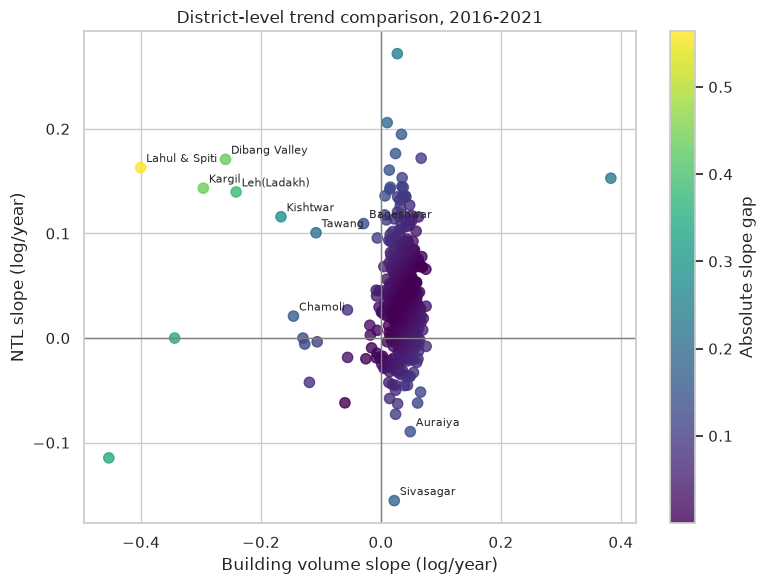

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    trend_df["vol_slope"],
    trend_df["ntl_slope"],
    c=trend_df["slope_gap"],
    cmap="viridis",
    s=55,
    alpha=0.8,
)

for _, row in strong_disagree.head(10).iterrows():
    ax.annotate(row["d_name"], (row["vol_slope"], row["ntl_slope"]), xytext=(4, 4), textcoords="offset points", fontsize=8)

ax.axhline(0, color="gray", linewidth=1)
ax.axvline(0, color="gray", linewidth=1)
ax.set_xlabel("Building volume slope (log/year)")
ax.set_ylabel("NTL slope (log/year)")
ax.set_title("District-level trend comparison, 2016-2021")
fig.colorbar(scatter, ax=ax, label="Absolute slope gap")
plt.tight_layout()
plt.show()

In [6]:
trend_df[trend_df["vol_slope"]==trend_df["vol_slope"].max()]

,pc11_s_id,pc11_d_id,d_name,vol_slope,ntl_slope,vol_start,vol_end,ntl_start,ntl_end,years,vol_trend,ntl_trend,slope_gap,n_intervals,vol_growth_rate,ntl_growth_rate,pair_type
8,31,587,Lakshadweep,0.38313,0.152858,1.372641e+06,1.900113e+07,26.305,60.91,"(2016, 2017, 2018, 2019, 2020, 2021)",growing,growing,0.230273,5,0.691393,0.182851,both growing


In [7]:
trend_df

,pc11_s_id,pc11_d_id,d_name,vol_slope,ntl_slope,vol_start,vol_end,ntl_start,ntl_end,years,vol_trend,ntl_trend,slope_gap,n_intervals,vol_growth_rate,ntl_growth_rate,pair_type
0,2,25,Lahul & Spiti,-0.400803,0.162973,2.112289e+08,2.905384e+07,12.270000,24.460001,"(2016, 2017, 2018, 2019, 2020, 2021)",declining,growing,0.563776,5,-0.327503,0.147948,volume DOWN / ntl UP (opposite)
1,1,4,Kargil,-0.296239,0.143302,2.693438e+08,4.998301e+07,4449.337143,9424.333923,"(2016, 2017, 2018, 2019, 2020, 2021)",declining,growing,0.439541,5,-0.285992,0.161960,volume DOWN / ntl UP (opposite)
2,12,257,Dibang Valley,-0.259325,0.170867,1.413291e+07,3.764807e+06,21.595000,67.539999,"(2016, 2017, 2018, 2019, 2020, 2021)",declining,growing,0.430192,5,-0.232458,0.256150,volume DOWN / ntl UP (opposite)
3,1,3,Leh(Ladakh),-0.241602,0.139665,4.135844e+08,1.170770e+08,14244.138123,28800.888306,"(2016, 2017, 2018, 2019, 2020, 2021)",declining,growing,0.381267,5,-0.223071,0.151208,volume DOWN / ntl UP (opposite)
4,12,260,Anjaw,-0.344141,0.000000,4.111819e+07,7.135823e+06,0.000000,0.000000,"(2016, 2017, 2018, 2019, 2020, 2021)",declining,stagnant,0.344141,5,-0.295498,NaN,volume declining / ntl flat
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
635,9,163,Kanpur Dehat,0.048041,0.048340,2.404193e+08,2.996492e+08,57969.864258,78377.470215,"(2016, 2017, 2018, 2019, 2020, 2021)",growing,growing,0.000299,5,0.045030,0.062179,both growing
636,33,602,Thiruvallur,0.036860,0.037135,8.352272e+08,1.009166e+09,510295.480469,624185.902344,"(2016, 2017, 2018, 2019, 2020, 2021)",growing,growing,0.000275,5,0.038560,0.041114,both growing
637,27,522,Ahmadnagar,0.033385,0.033647,8.491260e+08,9.709622e+08,214081.832031,251698.507812,"(2016, 2017, 2018, 2019, 2020, 2021)",growing,growing,0.000262,5,0.027179,0.032904,both growing
638,19,339,Bankura,0.025017,0.025188,5.874190e+08,6.676802e+08,54326.090820,60022.520020,"(2016, 2017, 2018, 2019, 2020, 2021)",growing,growing,0.000171,5,0.025945,0.020143,both growing


In [8]:
# Save a concise summary for later reuse.
summary_cols = [
    "pc11_s_id", "pc11_d_id", "d_name", "vol_slope", "ntl_slope", "vol_trend", "ntl_trend",
    "vol_growth_rate", "ntl_growth_rate", "slope_gap", "pair_type"
]
trend_df[summary_cols].to_csv(root / "volume_ntl_trends_summary.csv", index=False)
print("Saved summary to:", root / "volume_ntl_trends_summary.csv")

Saved summary to: /home/crystallikelaw/Documents/xkdr/GIT/India-Built-and-Lit/volume_ntl_trends_summary.csv


In [9]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

root = Path.cwd()
bv_path = root / "docs" / "data" / "bv_annual.csv"
ntl_path = root / "docs" / "data" / "viirs_monthly.csv"

bv = pd.read_csv(bv_path).rename(columns={"volume_m3": "building_volume_m3"})
viirs = pd.read_csv(ntl_path)

bv["d_name"] = bv["d_name"].fillna("missing")
viirs["d_name"] = viirs["d_name"].fillna("missing")

id_cols = ["pc11_s_id", "pc11_d_id", "d_name"]

ntl_yearly = (
    viirs.groupby(id_cols + ["year"], as_index=False)
    .agg(
        ntl_sum_radiance=("sum_radiance", "sum"),
        ntl_mean_radiance=("mean_radiance", "mean"),
        months_covered=("month", "nunique"),
    )
)

# Cap at 2021: BV for 2022+ shows an implausible sharp fall rather than the
# expected monotonic increase, so it's excluded from trend comparisons.
common_years = sorted(set(bv["year"]).intersection(ntl_yearly["year"]) & set(range(2016, 2022)))
bv_common = bv[bv["year"].isin(common_years)].copy()
ntl_common = ntl_yearly[ntl_yearly["year"].isin(common_years)].copy()

merged = bv_common.merge(ntl_common, on=id_cols + ["year"], how="inner")

merged["volume_rank"] = merged["building_volume_m3"].rank(pct=True)
merged["ntl_rank"] = merged["ntl_sum_radiance"].rank(pct=True)
merged["vol_to_ntl"] = merged["building_volume_m3"] / merged["ntl_sum_radiance"].replace(0, np.nan)

summary_rows = []
for (state_id, district_id, district_name), group in merged.groupby(["pc11_s_id", "pc11_d_id", "d_name"]):
    group = group.sort_values("year")
    if len(group) < 3:
        continue

    x = group["year"].to_numpy()
    vol = group["building_volume_m3"].to_numpy(dtype=float)
    ntl = group["ntl_sum_radiance"].to_numpy(dtype=float)

    if not (np.all(np.isfinite(vol)) and np.all(np.isfinite(ntl))):
        continue

    vol_slope = np.polyfit(x, vol, 1)[0]
    ntl_slope = np.polyfit(x, ntl, 1)[0]

    vol_growth = np.nan
    ntl_growth = np.nan
    if vol[0] != 0 and ntl[0] != 0:
        vol_growth = vol[-1] / vol[0] - 1
        ntl_growth = ntl[-1] / ntl[0] - 1

    summary_rows.append(
        {
            "pc11_s_id": state_id,
            "pc11_d_id": district_id,
            "d_name": district_name,
            "years": len(group),
            "vol_slope": vol_slope,
            "ntl_slope": ntl_slope,
            "slope_gap": abs(vol_slope - ntl_slope),
            "vol_growth_rate": vol_growth,
            "ntl_growth_rate": ntl_growth,
            "trend_pair": (
                ("growing" if vol_slope > 0 else "declining" if vol_slope < 0 else "flat")
                + " / "
                + ("growing" if ntl_slope > 0 else "declining" if ntl_slope < 0 else "flat")
            ),
            "mean_volume_m3": group["building_volume_m3"].mean(),
            "mean_ntl_sum_radiance": group["ntl_sum_radiance"].mean(),
            "mean_vol_to_ntl": group["vol_to_ntl"].replace([np.inf, -np.inf], np.nan).mean(),
        }
    )

trend_df = pd.DataFrame(summary_rows)
same_direction = np.sign(trend_df["vol_slope"]).astype(int) == np.sign(trend_df["ntl_slope"]).astype(int)
strong_agree = trend_df[same_direction].sort_values(["slope_gap", "mean_volume_m3"], ascending=[True, False]).head(10)
strong_disagree = trend_df[~same_direction].sort_values(["slope_gap", "mean_volume_m3"], ascending=[False, False]).head(10)
strong_disagree_dir = trend_df[~same_direction].sort_values("slope_gap", ascending=False).head(10)

high_volume_low_ntl = (
    merged[(merged["volume_rank"] >= 0.8) & (merged["ntl_rank"] <= 0.2)]
    .sort_values(["building_volume_m3", "ntl_sum_radiance"], ascending=[False, True])
    [["pc11_s_id", "pc11_d_id", "d_name", "year", "building_volume_m3", "ntl_sum_radiance", "vol_to_ntl"]]
)

volume_low_ntl_rank = (
    merged.sort_values(["vol_to_ntl", "building_volume_m3", "ntl_sum_radiance"], ascending=[False, False, True])
    [["pc11_s_id", "pc11_d_id", "d_name", "year", "building_volume_m3", "ntl_sum_radiance", "vol_to_ntl"]]
    .head(20)
)

print(f"Common years used: {common_years[0]}-{common_years[-1]} ({len(common_years)} years)")
print(f"Districts compared: {trend_df.shape[0]}")
print()
print("Top agreement by similar trend slopes:")
display(strong_agree[["pc11_s_id", "pc11_d_id", "d_name", "trend_pair", "vol_slope", "ntl_slope", "slope_gap", "mean_volume_m3", "mean_ntl_sum_radiance"]])
print()
print("Top disagreement by slope gap:")
display(strong_disagree[["pc11_s_id", "pc11_d_id", "d_name", "trend_pair", "vol_slope", "ntl_slope", "slope_gap", "mean_volume_m3", "mean_ntl_sum_radiance"]])
print()
print("Strong opposite-direction disagreements:")
display(strong_disagree_dir[["pc11_s_id", "pc11_d_id", "d_name", "trend_pair", "vol_slope", "ntl_slope", "slope_gap"]])
print()
print("High building volume / low NTL district-years:")
display(high_volume_low_ntl.head(20))
print()
print("Highest building-volume-to-NTL ratios:")
display(volume_low_ntl_rank)


Common years used: 2016-2021 (6 years)
Districts compared: 641

Top agreement by similar trend slopes:


,pc11_s_id,pc11_d_id,d_name,trend_pair,vol_slope,ntl_slope,slope_gap,mean_volume_m3,mean_ntl_sum_radiance
268,13,268,Longleng,growing / growing,10255.442414,12.017151,10243.425262,1.157271e+07,504.215081
288,15,288,Saiha,growing / growing,51527.007604,26.110909,51500.896695,1.033071e+07,373.981986
638,35,638,Nicobars,growing / growing,69381.704673,61.744683,69319.959990,1.017471e+07,471.099736
636,34,636,Mahe,growing / growing,159477.096571,31.240819,159445.855752,1.154943e+07,676.915639
284,15,284,Champhai,growing / growing,162990.991915,106.568603,162884.423312,1.705046e+07,898.722873
264,13,264,Wokha,growing / growing,199414.167447,101.043103,199313.124344,2.382873e+07,2372.473389
269,13,269,Kiphire,growing / growing,243885.868961,4.348673,243881.520288,1.160078e+07,860.532723
494,25,494,Diu,growing / growing,279251.667209,44.466619,279207.200590,1.234577e+07,8094.729451
295,17,295,South Garo Hills,growing / growing,295478.660462,47.264261,295431.396201,2.865262e+07,214.800283
603,33,603,Chennai,growing / growing,333450.597078,7302.517969,326148.079110,6.037456e+08,298246.600911



Top disagreement by slope gap:


,pc11_s_id,pc11_d_id,d_name,trend_pair,vol_slope,ntl_slope,slope_gap,mean_volume_m3,mean_ntl_sum_radiance
0,1,0,missing,declining / growing,-2.161733e+08,956.939425,2.161742e+08,1.486523e+09,2.347172e+04
572,29,572,Bangalore,growing / declining,1.107603e+08,-5209.040625,1.107655e+08,2.586002e+09,2.580131e+06
3,1,3,Leh(Ladakh),declining / growing,-6.100618e+07,2840.926899,6.100902e+07,2.742890e+08,2.009636e+04
157,9,157,Lucknow,growing / declining,5.146192e+07,-7978.879018,5.146990e+07,9.876858e+08,1.096833e+06
104,8,104,Alwar,growing / declining,4.098812e+07,-1052.817857,4.098917e+07,8.174051e+08,2.970082e+05
505,27,505,Nagpur,growing / declining,3.994276e+07,-6222.937388,3.994899e+07,9.749465e+08,5.839447e+05
343,19,343,South Twenty Four Parganas,growing / declining,3.864177e+07,-691.276925,3.864246e+07,1.292101e+09,2.231711e+05
4,1,4,Kargil,declining / growing,-3.795542e+07,929.466690,3.795635e+07,1.298381e+08,6.073578e+03
175,9,175,Allahabad,growing / declining,3.710127e+07,-3980.010268,3.710525e+07,9.354132e+08,4.921058e+05
25,2,25,Lahul & Spiti,declining / growing,-3.703047e+07,3.183000,3.703048e+07,1.289710e+08,1.906250e+01



Strong opposite-direction disagreements:


,pc11_s_id,pc11_d_id,d_name,trend_pair,vol_slope,ntl_slope,slope_gap
0,1,0,missing,declining / growing,-2.161733e+08,956.939425,2.161742e+08
572,29,572,Bangalore,growing / declining,1.107603e+08,-5209.040625,1.107655e+08
3,1,3,Leh(Ladakh),declining / growing,-6.100618e+07,2840.926899,6.100902e+07
157,9,157,Lucknow,growing / declining,5.146192e+07,-7978.879018,5.146990e+07
104,8,104,Alwar,growing / declining,4.098812e+07,-1052.817857,4.098917e+07
505,27,505,Nagpur,growing / declining,3.994276e+07,-6222.937388,3.994899e+07
343,19,343,South Twenty Four Parganas,growing / declining,3.864177e+07,-691.276925,3.864246e+07
4,1,4,Kargil,declining / growing,-3.795542e+07,929.466690,3.795635e+07
175,9,175,Allahabad,growing / declining,3.710127e+07,-3980.010268,3.710525e+07
25,2,25,Lahul & Spiti,declining / growing,-3.703047e+07,3.183000,3.703048e+07



High building volume / low NTL district-years:


,pc11_s_id,pc11_d_id,d_name,year,building_volume_m3,ntl_sum_radiance,vol_to_ntl



Highest building-volume-to-NTL ratios:


,pc11_s_id,pc11_d_id,d_name,year,building_volume_m3,ntl_sum_radiance,vol_to_ntl
150,2,25,Lahul & Spiti,2016,2.112289e+08,12.270000,1.721507e+07
151,2,25,Lahul & Spiti,2017,1.891438e+08,14.010000,1.350063e+07
152,2,25,Lahul & Spiti,2018,1.236418e+08,13.350000,9.261558e+06
153,2,25,Lahul & Spiti,2019,1.781955e+08,22.510000,7.916280e+06
1446,11,241,North District,2016,3.301233e+08,106.633970,3.095855e+06
1447,11,241,North District,2017,1.558234e+08,96.298084,1.618136e+06
154,2,25,Lahul & Spiti,2020,4.256216e+07,27.774999,1.532391e+06
155,2,25,Lahul & Spiti,2021,2.905384e+07,24.460001,1.187810e+06
1448,11,241,North District,2018,8.960536e+07,79.978163,1.120373e+06
1450,11,241,North District,2020,5.452040e+07,65.779737,8.288327e+05


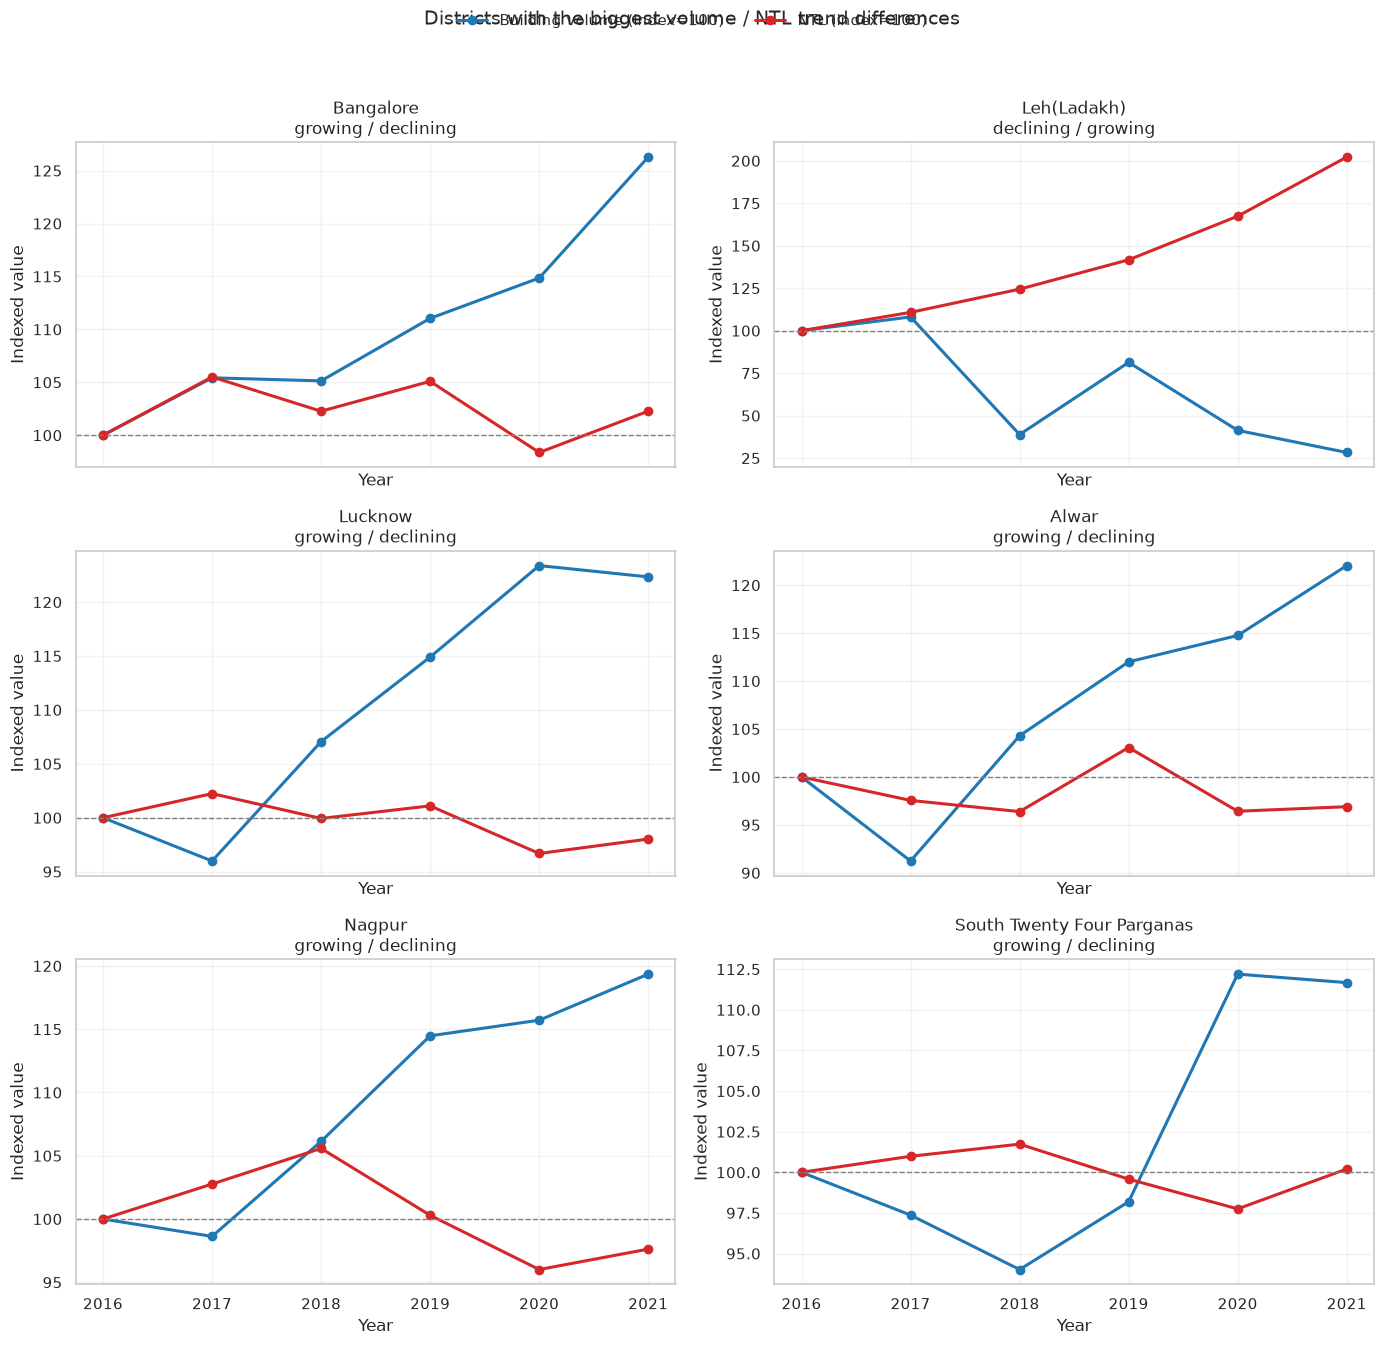

In [10]:
import math

plot_districts = (
    trend_df[
        trend_df["d_name"].ne("missing")
        & trend_df["trend_pair"].isin(["declining / growing", "growing / declining"]) 
    ]
    .sort_values("slope_gap", ascending=False)
    [["pc11_s_id", "pc11_d_id", "d_name"]]
    .drop_duplicates()
    .head(6)
    .to_dict("records")
)

if not plot_districts:
    print("No opposite-direction districts found to plot.")
else:
    ncols = 2
    nrows = math.ceil(len(plot_districts) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.5 * nrows), sharex=True)
    axes = np.atleast_1d(axes).ravel()

    for ax, district in zip(axes, plot_districts):
        district_df = merged[
            (merged["pc11_s_id"] == district["pc11_s_id"])
            & (merged["pc11_d_id"] == district["pc11_d_id"])
            & (merged["d_name"] == district["d_name"])
        ].sort_values("year")

        volume_norm = district_df["building_volume_m3"] / district_df["building_volume_m3"].iloc[0] * 100
        ntl_norm = district_df["ntl_sum_radiance"] / district_df["ntl_sum_radiance"].iloc[0] * 100

        ax.plot(district_df["year"], volume_norm, marker="o", linewidth=2.2, label="Building volume (index=100)", color="#1f77b4")
        ax.plot(district_df["year"], ntl_norm, marker="o", linewidth=2.2, label="NTL (index=100)", color="#d62728")

        trend_label = trend_df.loc[(trend_df['pc11_s_id'] == district['pc11_s_id']) & (trend_df['pc11_d_id'] == district['pc11_d_id']), 'trend_pair'].iloc[0]
        ax.set_title(f"{district['d_name']}\n{trend_label}")
        ax.set_xlabel("Year")
        ax.set_ylabel("Indexed value")
        ax.axhline(100, color="gray", linewidth=1, linestyle="--")
        ax.grid(True, alpha=0.25)

    for ax in axes[len(plot_districts):]:
        ax.set_visible(False)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
    fig.suptitle("Districts with the biggest volume / NTL trend differences", y=0.995, fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


In [15]:
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from matplotlib.lines import Line2D


def _coerce_int_like(value):
    try:
        return int(value)
    except (TypeError, ValueError):
        return value


def _resolve_district_selector(selector, district_frame: pd.DataFrame) -> pd.DataFrame:
    """Resolve district selector to rows in district_frame.

    Supported selector formats:
    - "District Name" (exact first, then case-insensitive)
    - (state_id, district_id)
    - {"pc11_s_id": ..., "pc11_d_id": ...}
    """
    if isinstance(selector, str):
        exact = district_frame[district_frame["d_name"] == selector]
        if not exact.empty:
            return exact

        s = selector.strip().lower()
        return district_frame[district_frame["d_name"].astype(str).str.strip().str.lower() == s]

    if isinstance(selector, tuple) and len(selector) == 2:
        state_id, district_id = selector
        state_id = _coerce_int_like(state_id)
        district_id = _coerce_int_like(district_id)
        return district_frame[
            (district_frame["pc11_s_id"].map(_coerce_int_like) == state_id)
            & (district_frame["pc11_d_id"].map(_coerce_int_like) == district_id)
        ]

    if isinstance(selector, dict):
        if {"pc11_s_id", "pc11_d_id"}.issubset(selector.keys()):
            state_id = _coerce_int_like(selector["pc11_s_id"])
            district_id = _coerce_int_like(selector["pc11_d_id"])
            return district_frame[
                (district_frame["pc11_s_id"].map(_coerce_int_like) == state_id)
                & (district_frame["pc11_d_id"].map(_coerce_int_like) == district_id)
            ]

    raise ValueError(
        "Each district must be a name, (state_id, district_id) tuple, "
        "or {'pc11_s_id': ..., 'pc11_d_id': ...} dict."
    )


def _normalize_to_index_100(series: pd.Series) -> pd.Series:
    valid = series.replace([np.inf, -np.inf], np.nan).dropna()
    if valid.empty or valid.iloc[0] == 0:
        return pd.Series(np.nan, index=series.index)
    return series / valid.iloc[0] * 100


def plot_ntl_bv_timeline(
    *districts,
    bv_df: pd.DataFrame | None = None,
    viirs_df: pd.DataFrame | None = None,
    start: str | None = None,
    end: str | None = None,
    figsize: tuple[int, int] = (14, 8),
    alpha: float = 0.9,
    strict: bool = False,
    verbose: bool = True,
) -> tuple[plt.Figure, plt.Axes]:
    """Plot normalized monthly NTL (dashed) and yearly BV (solid) for selected districts.

    Each district gets a unique color. NTL is dashed and BV is solid.
    By default, all available dates are plotted.
    """
    if len(districts) == 0:
        raise ValueError("Provide at least one district selector.")

    if bv_df is None:
        if "bv" not in globals():
            raise ValueError("No bv_df passed and global bv not found.")
        bv_df = bv.copy()
    else:
        bv_df = bv_df.copy()

    if viirs_df is None:
        if "viirs" not in globals():
            raise ValueError("No viirs_df passed and global viirs not found.")
        viirs_df = viirs.copy()
    else:
        viirs_df = viirs_df.copy()

    volume_col = "building_volume_m3" if "building_volume_m3" in bv_df.columns else "volume_m3"
    if volume_col not in bv_df.columns:
        raise ValueError("Could not find yearly BV column (volume_m3 or building_volume_m3).")

    if "sum_radiance" not in viirs_df.columns:
        raise ValueError("Could not find monthly NTL column sum_radiance.")

    if "date" not in viirs_df.columns:
        if {"year", "month"}.issubset(viirs_df.columns):
            viirs_df["date"] = pd.to_datetime(
                viirs_df["year"].astype(str) + "-" + viirs_df["month"].astype(str) + "-01"
            )
        else:
            raise ValueError("VIIRS data needs either date or both year and month columns.")

    viirs_df["date"] = pd.to_datetime(viirs_df["date"])
    viirs_df["year"] = viirs_df["date"].dt.year.astype(int)
    bv_df["year"] = bv_df["year"].astype(int)

    id_cols = ["pc11_s_id", "pc11_d_id", "d_name"]

    viirs_monthly = (
        viirs_df.groupby(id_cols + ["date", "year"], as_index=False)["sum_radiance"]
        .sum()
        .rename(columns={"sum_radiance": "ntl_sum_radiance"})
    )

    bv_yearly = (
        bv_df.groupby(id_cols + ["year"], as_index=False)[volume_col]
        .sum()
        .rename(columns={volume_col: "building_volume_m3"})
    )

    district_universe = viirs_monthly[id_cols].drop_duplicates().merge(
        bv_yearly[id_cols].drop_duplicates(),
        on=id_cols,
        how="inner",
    )

    selected_rows = []
    seen = set()
    missing = []

    for selector in districts:
        matched = _resolve_district_selector(selector, district_universe)
        if matched.empty:
            missing.append(selector)
            continue

        for _, row in matched.iterrows():
            key = (row["pc11_s_id"], row["pc11_d_id"], row["d_name"])
            if key in seen:
                continue
            seen.add(key)
            selected_rows.append(row.to_dict())

    if missing and strict:
        raise ValueError(f"No district found for selector(s): {missing}")

    if not selected_rows:
        sample = district_universe[["pc11_s_id", "pc11_d_id", "d_name"]].head(10)
        raise ValueError(
            "None of the requested selectors matched. Example available districts:\n"
            + sample.to_string(index=False)
        )

    if missing and verbose:
        print(f"Skipping {len(missing)} unmatched selector(s): {missing}")

    selected = pd.DataFrame(selected_rows)

    monthly = viirs_monthly.merge(selected, on=id_cols, how="inner")
    monthly = monthly.merge(bv_yearly, on=id_cols + ["year"], how="left")

    if start is not None:
        monthly = monthly[monthly["date"] >= pd.to_datetime(start)]
    if end is not None:
        monthly = monthly[monthly["date"] <= pd.to_datetime(end)]

    if monthly.empty:
        raise ValueError("No data left after applying district/date filters.")

    monthly = monthly.sort_values(["pc11_s_id", "pc11_d_id", "date"]).copy()
    monthly["ntl_index"] = monthly.groupby(id_cols)["ntl_sum_radiance"].transform(_normalize_to_index_100)

    yearly_points = monthly[id_cols + ["year", "building_volume_m3"]].drop_duplicates().copy()
    yearly_points["date"] = pd.to_datetime(yearly_points["year"].astype(str) + "-07-01")
    yearly_points = yearly_points.sort_values(["pc11_s_id", "pc11_d_id", "date"])
    yearly_points["bv_index"] = yearly_points.groupby(id_cols)["building_volume_m3"].transform(_normalize_to_index_100)

    district_keys = [tuple(x) for x in selected[id_cols].drop_duplicates().itertuples(index=False, name=None)]
    cmap = plt.get_cmap("tab20")
    district_colors = {k: cmap(i % 20) for i, k in enumerate(district_keys)}

    fig, ax = plt.subplots(figsize=figsize)

    for key, g_ntl in monthly.groupby(id_cols):
        state_id, district_id, district_name = key
        color = district_colors[key]
        g_bv = yearly_points[
            (yearly_points["pc11_s_id"] == state_id)
            & (yearly_points["pc11_d_id"] == district_id)
            & (yearly_points["d_name"] == district_name)
        ]

        district_label = f"{district_name} ({int(state_id)}-{int(district_id)})"

        ax.plot(
            g_ntl["date"],
            g_ntl["ntl_index"],
            linestyle="--",
            color=color,
            linewidth=1.7,
            alpha=alpha,
        )

        ax.plot(
            g_bv["date"],
            g_bv["bv_index"],
            linestyle="-",
            marker="o",
            markersize=4,
            color=color,
            linewidth=2.0,
            alpha=alpha,
        )

    ax.axhline(100, color="gray", linewidth=1, linestyle=":")
    ax.set_title("Normalized Growth Comparison: Monthly NTL (dashed) vs Yearly BV (solid)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Index (first value = 100)")
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(True, alpha=0.25)

    district_handles = [
        Line2D(
            [0],
            [0],
            color=district_colors[(r.pc11_s_id, r.pc11_d_id, r.d_name)],
            lw=3,
            label=f"{r.d_name} ({int(r.pc11_s_id)}-{int(r.pc11_d_id)})",
        )
        for r in selected[id_cols].drop_duplicates().itertuples(index=False)
    ]

    style_handles = [
        Line2D([0], [0], color="black", lw=2, linestyle="--", label="NTL monthly"),
        Line2D([0], [0], color="black", lw=2, linestyle="-", marker="o", label="BV yearly"),
    ]

    legend1 = ax.legend(
        handles=district_handles,
        title="District Color",
        loc="upper left",
        frameon=True,
        fontsize=8,
    )
    ax.add_artist(legend1)
    ax.legend(handles=style_handles, title="Line Style", loc="upper right")

    if verbose:
        plotted = selected[["pc11_s_id", "pc11_d_id", "d_name"]].drop_duplicates()
        print("Plotted districts:")
        print(plotted.to_string(index=False))

    plt.tight_layout()
    return fig, ax


# Example usage (district names; all dates by default):
# plot_ntl_bv_timeline(
#     "Bengaluru",
#     "Mumbai",
#     "Pune",
#     strict=False,
#     verbose=True,
# )

Plotted districts:
 pc11_s_id  pc11_d_id          d_name
        12        255 Lower Subansiri
        33        624           Theni
        23        442         Rajgarh
         9        169          Mahoba


(<Figure size 1400x800 with 1 Axes>,
 <Axes: title={'center': 'Normalized Growth Comparison: Monthly NTL (dashed) vs Yearly BV (solid)'}, xlabel='Date', ylabel='Index (first value = 100)'>)

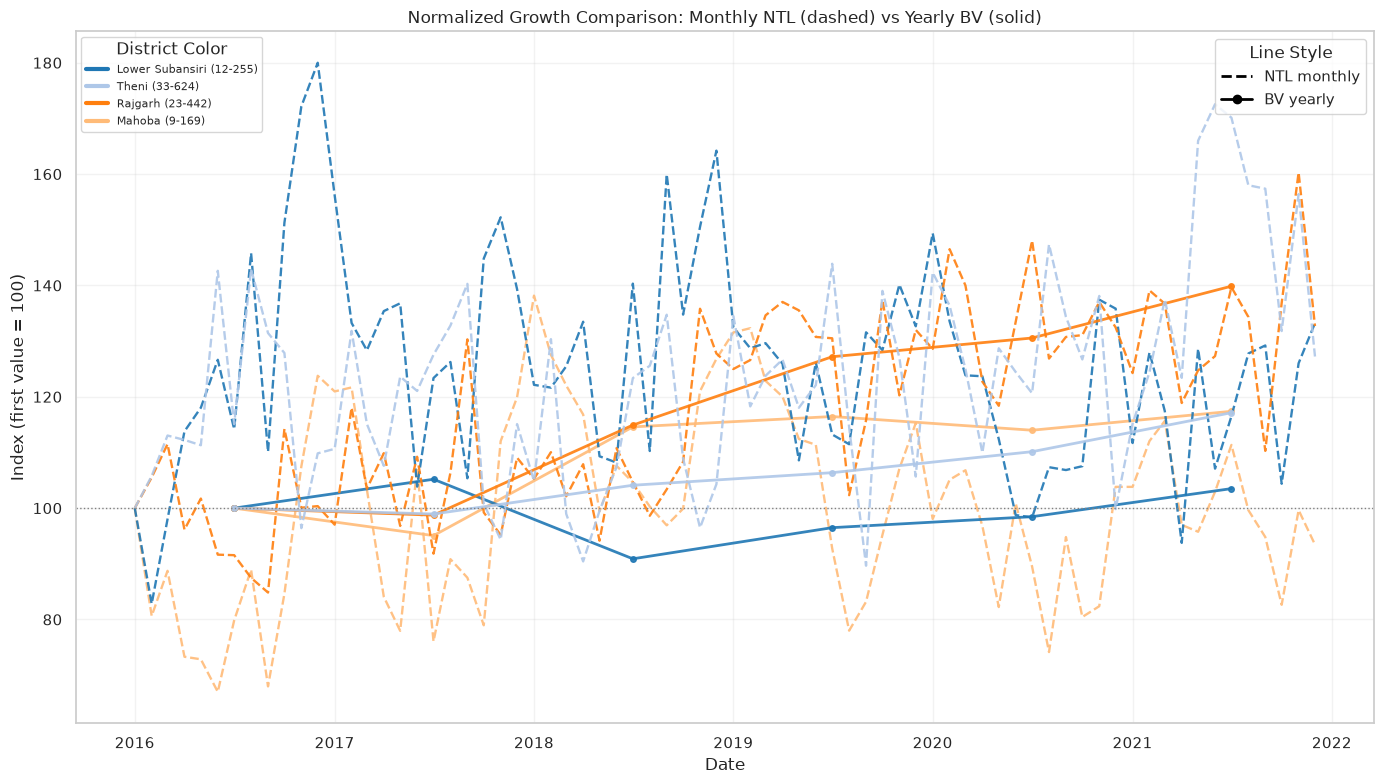

In [28]:
sample_district_names = (
    merged.loc[merged["d_name"].ne("missing"), "d_name"]
    .dropna()
    .drop_duplicates()
    .head(4)
    .tolist()
)

plot_ntl_bv_timeline(
    *['Lower Subansiri', 'Theni', 'Rajgarh', 'Mahoba'],
    strict=True,
    verbose=True,
    start="2016-01-01",
    end="2021-12-31"
)

In [17]:
sample_district_names

['Kupwara', 'Badgam', 'Leh(Ladakh)', 'Kargil']

In [ ]:
['Kupwara', 'Badgam', 'Lower Subansiri']

In [24]:
bv.columns

Index(['pc11_s_id', 'pc11_d_id', 'd_name', 'year', 'footprint_m2',
       'building_volume_m3', 'mean_height_m'],
      dtype='str')

In [25]:
bv[bv.d_name == 'Rajgarh']

,pc11_s_id,pc11_d_id,d_name,year,footprint_m2,building_volume_m3,mean_height_m
3536,23,442,Rajgarh,2016,5.214915e+08,2.233792e+08,0.428347
3537,23,442,Rajgarh,2017,5.732768e+08,2.205634e+08,0.384742
3538,23,442,Rajgarh,2018,5.898842e+08,2.566964e+08,0.435164
3539,23,442,Rajgarh,2019,6.306993e+08,2.841301e+08,0.450500
3540,23,442,Rajgarh,2020,7.075932e+08,2.916389e+08,0.412156
3541,23,442,Rajgarh,2021,6.670239e+08,3.124356e+08,0.468402
3542,23,442,Rajgarh,2022,6.071985e+08,2.399551e+08,0.395184
3543,23,442,Rajgarh,2023,6.908668e+08,2.723254e+08,0.394179


In [26]:
viirs[viirs.d_name == 'Rajgarh']

,pc11_s_id,pc11_d_id,d_name,year,month,date,sum_radiance,mean_radiance,n_pixels
63206,23,442,Rajgarh,2014,1,2014-01-01,3420.951660,0.107163,31923
63207,23,442,Rajgarh,2014,2,2014-02-01,3551.334961,0.111247,31923
63208,23,442,Rajgarh,2014,3,2014-03-01,3063.008301,0.095950,31923
63209,23,442,Rajgarh,2014,4,2014-04-01,3099.240723,0.097085,31923
63210,23,442,Rajgarh,2014,5,2014-05-01,3078.617920,0.096439,31923
...,...,...,...,...,...,...,...,...,...
63344,23,442,Rajgarh,2025,8,2025-08-01,4506.467773,0.141167,31923
63345,23,442,Rajgarh,2025,9,2025-09-01,5142.341797,0.161086,31923
63346,23,442,Rajgarh,2025,10,2025-10-01,4354.994629,0.136422,31923
63347,23,442,Rajgarh,2025,11,2025-11-01,4775.746094,0.149602,31923


Plotted districts:
 pc11_s_id  pc11_d_id      d_name
         1          1     Kupwara
         1          2      Badgam
         1          3 Leh(Ladakh)
         1          4      Kargil


(<Figure size 1400x800 with 1 Axes>,
 <Axes: title={'center': 'Normalized Growth: Yearly BV (line) and Yearly-Average NTL (points)'}, xlabel='Year', ylabel='Index (first value = 100)'>)

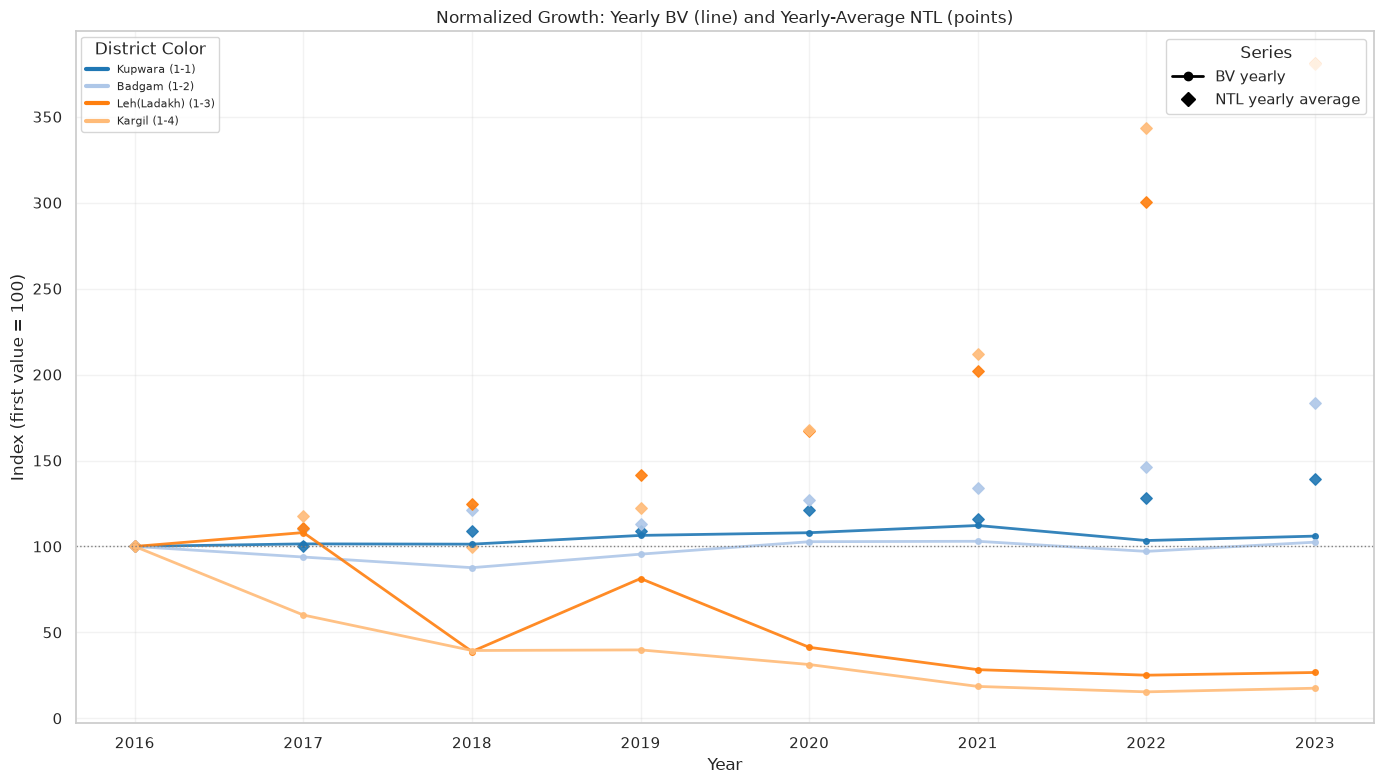

In [30]:
plot_ntl_yearly_avg_points(
    *sample_district_names,
    strict=False,
    verbose=True,
)

Plotted districts:
 pc11_s_id  pc11_d_id    d_name
        23        442   Rajgarh
        18        311 Sivasagar
        27        501     Akola


(<Figure size 1400x800 with 1 Axes>,
 <Axes: title={'center': 'Normalized Growth: Yearly BV (line) and Yearly-Average NTL (dashed line)'}, xlabel='Year', ylabel='Index (first value = 100)'>)

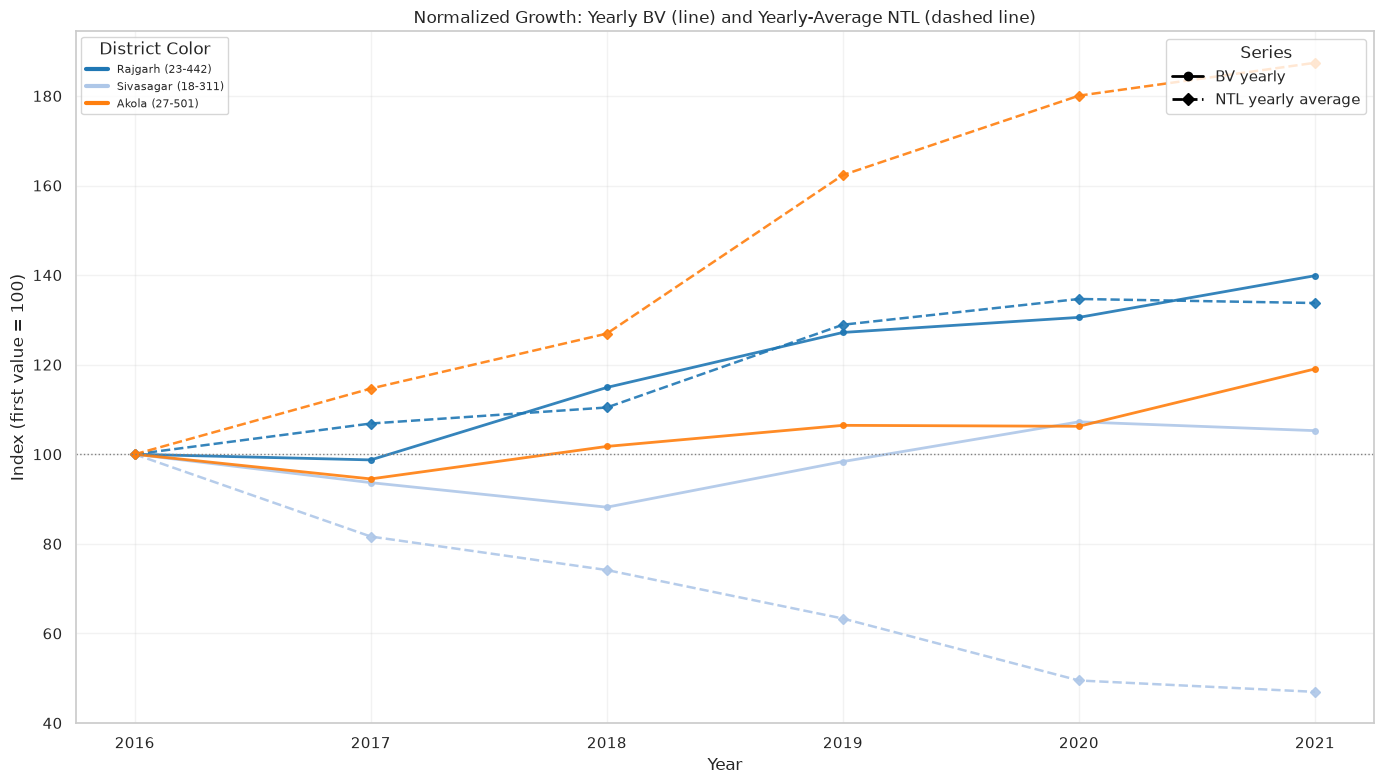

In [ ]:
def plot_ntl_yearly_avg_points(
    *districts,
    bv_df: pd.DataFrame | None = None,
    viirs_df: pd.DataFrame | None = None,
    start_year: int | None = None,
    end_year: int | None = None,
    figsize: tuple[int, int] = (14, 8),
    alpha: float = 0.9,
    strict: bool = False,
    verbose: bool = True,
) -> tuple[plt.Figure, plt.Axes]:
    """Plot normalized yearly BV line + normalized yearly-average NTL line/points.

    - Districts can be passed as names, (state_id, district_id) tuples, or id dicts.
    - BV is shown as a solid line with circles.
    - NTL yearly average is shown as a dashed line with diamond markers.
    - Each district has a unique color.
    """
    if len(districts) == 0:
        raise ValueError("Provide at least one district selector.")

    if bv_df is None:
        if "bv" not in globals():
            raise ValueError("No bv_df passed and global bv not found.")
        bv_df = bv.copy()
    else:
        bv_df = bv_df.copy()

    if viirs_df is None:
        if "viirs" not in globals():
            raise ValueError("No viirs_df passed and global viirs not found.")
        viirs_df = viirs.copy()
    else:
        viirs_df = viirs_df.copy()

    volume_col = "building_volume_m3" if "building_volume_m3" in bv_df.columns else "volume_m3"
    if volume_col not in bv_df.columns:
        raise ValueError("Could not find yearly BV column (volume_m3 or building_volume_m3).")

    if "sum_radiance" not in viirs_df.columns:
        raise ValueError("Could not find NTL column sum_radiance.")

    if "date" not in viirs_df.columns:
        if {"year", "month"}.issubset(viirs_df.columns):
            viirs_df["date"] = pd.to_datetime(
                viirs_df["year"].astype(str) + "-" + viirs_df["month"].astype(str) + "-01"
            )
        else:
            raise ValueError("VIIRS data needs either date or both year and month columns.")

    viirs_df["date"] = pd.to_datetime(viirs_df["date"])
    viirs_df["year"] = viirs_df["date"].dt.year.astype(int)
    bv_df["year"] = bv_df["year"].astype(int)

    id_cols = ["pc11_s_id", "pc11_d_id", "d_name"]

    # Aggregate monthly NTL into yearly mean radiance.
    ntl_yearly_avg = (
        viirs_df.groupby(id_cols + ["year"], as_index=False)["sum_radiance"]
        .mean()
        .rename(columns={"sum_radiance": "ntl_avg_radiance"})
    )

    bv_yearly = (
        bv_df.groupby(id_cols + ["year"], as_index=False)[volume_col]
        .sum()
        .rename(columns={volume_col: "building_volume_m3"})
    )

    district_universe = ntl_yearly_avg[id_cols].drop_duplicates().merge(
        bv_yearly[id_cols].drop_duplicates(),
        on=id_cols,
        how="inner",
    )

    selected_rows = []
    seen = set()
    missing = []

    for selector in districts:
        matched = _resolve_district_selector(selector, district_universe)
        if matched.empty:
            missing.append(selector)
            continue
        for _, row in matched.iterrows():
            key = (row["pc11_s_id"], row["pc11_d_id"], row["d_name"])
            if key in seen:
                continue
            seen.add(key)
            selected_rows.append(row.to_dict())

    if missing and strict:
        raise ValueError(f"No district found for selector(s): {missing}")

    if not selected_rows:
        sample = district_universe[["pc11_s_id", "pc11_d_id", "d_name"]].head(10)
        raise ValueError(
            "None of the requested selectors matched. Example available districts:\n"
            + sample.to_string(index=False)
        )

    if missing and verbose:
        print(f"Skipping {len(missing)} unmatched selector(s): {missing}")

    selected = pd.DataFrame(selected_rows)

    yearly = bv_yearly.merge(ntl_yearly_avg, on=id_cols + ["year"], how="inner")
    yearly = yearly.merge(selected, on=id_cols, how="inner")

    if start_year is not None:
        yearly = yearly[yearly["year"] >= int(start_year)]
    if end_year is not None:
        yearly = yearly[yearly["year"] <= int(end_year)]

    if yearly.empty:
        raise ValueError("No yearly data left after district/year filtering.")

    yearly = yearly.sort_values(["pc11_s_id", "pc11_d_id", "year"]).copy()
    yearly["bv_index"] = yearly.groupby(id_cols)["building_volume_m3"].transform(_normalize_to_index_100)
    yearly["ntl_avg_index"] = yearly.groupby(id_cols)["ntl_avg_radiance"].transform(_normalize_to_index_100)

    district_keys = [tuple(x) for x in selected[id_cols].drop_duplicates().itertuples(index=False, name=None)]
    cmap = plt.get_cmap("tab20")
    district_colors = {k: cmap(i % 20) for i, k in enumerate(district_keys)}

    fig, ax = plt.subplots(figsize=figsize)

    for key, g in yearly.groupby(id_cols):
        state_id, district_id, district_name = key
        color = district_colors[key]

        ax.plot(
            g["year"],
            g["bv_index"],
            linestyle="-",
            marker="o",
            markersize=4,
            linewidth=2.0,
            color=color,
            alpha=alpha,
        )

        ax.plot(
            g["year"],
            g["ntl_avg_index"],
            linestyle="--",
            marker="D",
            markersize=5,
            linewidth=1.8,
            color=color,
            alpha=alpha,
        )

    ax.axhline(100, color="gray", linewidth=1, linestyle=":")
    ax.set_title("Normalized Growth: Yearly BV (line) and Yearly-Average NTL (dashed line)")
    ax.set_xlabel("Year")
    ax.set_ylabel("Index (first value = 100)")
    ax.grid(True, alpha=0.25)

    district_handles = [
        Line2D(
            [0],
            [0],
            color=district_colors[(r.pc11_s_id, r.pc11_d_id, r.d_name)],
            lw=3,
            label=f"{r.d_name} ({int(r.pc11_s_id)}-{int(r.pc11_d_id)})",
        )
        for r in selected[id_cols].drop_duplicates().itertuples(index=False)
    ]

    style_handles = [
        Line2D([0], [0], color="black", lw=2, linestyle="-", marker="o", label="BV yearly"),
        Line2D([0], [0], color="black", lw=2, linestyle="--", marker="D", label="NTL yearly average"),
    ]

    legend1 = ax.legend(
        handles=district_handles,
        title="District Color",
        loc="upper left",
        frameon=True,
        fontsize=8,
    )
    ax.add_artist(legend1)
    ax.legend(handles=style_handles, title="Series", loc="upper right")

    if verbose:
        plotted = selected[["pc11_s_id", "pc11_d_id", "d_name"]].drop_duplicates()
        print("Plotted districts:")
        print(plotted.to_string(index=False))

    plt.tight_layout()
    return fig, ax


# Example:
plot_ntl_yearly_avg_points(
    'Rajgarh', 'Sivasagar', 'Akola',
    start_year="2016",
    end_year="2021"
)


#'Rajgarh' : Sustained growth
#'Sivasagar' : Sustained decline
# 'Akola' : NTL growth but BV stagnant

In [38]:
trend_df.sort_values(['ntl_growth_rate']).head(20)

,pc11_s_id,pc11_d_id,d_name,years,vol_slope,ntl_slope,slope_gap,vol_growth_rate,ntl_growth_rate,trend_pair,mean_volume_m3,mean_ntl_sum_radiance,mean_vol_to_ntl
311,18,311,Sivasagar,8,1.672387e+06,-7038.890375,1.679426e+06,-0.107593,-0.377298,growing / declining,3.072520e+08,74302.922119,4.457493e+03
241,11,241,North District,8,-3.553540e+07,-5.026421,3.553539e+07,-0.924485,-0.303433,declining / declining,9.443268e+07,79.784954,1.048178e+06
162,9,162,Auraiya,8,1.299784e+06,-5055.664987,1.304839e+06,0.010315,-0.220185,growing / declining,1.938516e+08,115659.499207,1.724343e+03
294,17,294,East Garo Hills,8,1.343842e+06,-15.189694,1.343857e+06,-0.014797,-0.216432,growing / declining,7.410413e+07,325.361455,2.342996e+05
161,9,161,Etawah,8,3.824530e+06,-3572.947202,3.828103e+06,0.102959,-0.186087,growing / declining,2.254971e+08,91652.568054,2.508294e+03
309,18,309,Tinsukia,8,4.513453e+06,-3408.065592,4.516861e+06,0.009945,-0.181184,growing / declining,2.984100e+08,211294.490967,1.439850e+03
639,35,639,North & Middle Andaman,8,3.180446e+05,1.378351,3.180432e+05,-0.018277,-0.180566,growing / growing,2.558990e+07,323.071792,8.017111e+04
107,8,107,Karauli,8,1.923691e+06,-1429.289949,1.925120e+06,0.093889,-0.158736,growing / declining,2.195299e+08,37714.965179,5.905403e+03
296,17,296,West Khasi Hills,8,2.390468e+05,-23.145724,2.390699e+05,-0.060227,-0.152871,growing / declining,7.026912e+07,981.226581,7.191950e+04
477,24,477,Jamnagar,8,-3.480771e+06,-24391.145322,3.456380e+06,-0.094864,-0.152190,declining / declining,5.123520e+08,658076.309082,7.884986e+02


In [45]:
trend_df[(trend_df.vol_growth_rate > -0.01) & (trend_df.vol_growth_rate < 0.01)].sort_values('ntl_growth_rate', ascending=False).head(20)

,pc11_s_id,pc11_d_id,d_name,years,vol_slope,ntl_slope,slope_gap,vol_growth_rate,ntl_growth_rate,trend_pair,mean_volume_m3,mean_ntl_sum_radiance,mean_vol_to_ntl
502,27,502,Washim,8,4.073006e+05,3580.953488,4.037197e+05,0.008705,1.703320,growing / growing,1.480716e+08,28210.719513,5728.885340
501,27,501,Akola,8,9.992327e+04,10439.056094,8.948421e+04,0.000590,1.234387,growing / growing,2.562022e+08,94591.646240,2903.860109
307,18,307,Lakhimpur,8,5.268994e+06,269.969650,5.268724e+06,-0.009741,1.101664,growing / growing,2.890223e+08,2486.086781,122340.546467
258,12,258,Lower Dibang Valley,8,1.202462e+05,144.140408,1.201021e+05,-0.005608,1.058172,growing / growing,1.684289e+07,1941.291477,8982.083015
482,24,482,Anand,8,1.104846e+06,10083.973569,1.094762e+06,-0.009914,0.968675,growing / growing,3.731992e+08,119691.408508,3241.290113
308,18,308,Dhemaji,8,3.950964e+06,480.967674,3.950483e+06,-0.006449,0.887072,growing / growing,1.912464e+08,5097.077267,39053.947291
13,1,13,Shupiyan,8,4.830881e+05,112.204228,4.829759e+05,-0.004722,0.882409,growing / growing,6.969091e+07,1305.268766,55528.011588
61,5,61,Garhwal,8,8.678905e+05,2904.949011,8.649855e+05,0.003344,0.805747,growing / growing,1.685116e+08,33502.402298,5226.587484
14,1,14,Anantnag,8,-4.147783e+04,655.509385,4.213334e+04,0.004472,0.750265,declining / growing,2.086268e+08,9373.391720,22963.625859
375,21,375,Kendujhar,8,4.254262e+06,12055.439221,4.242206e+06,-0.003411,0.743970,growing / growing,3.124569e+08,152235.331299,2115.394811


Plotted districts:
 pc11_s_id  pc11_d_id    d_name
        23        442   Rajgarh
        18        311 Sivasagar
        27        501     Akola


(<Figure size 1400x800 with 2 Axes>,
 (<Axes: title={'center': 'Original Units: Yearly BV (left axis) and Yearly-Average NTL (right axis)'}, xlabel='Year', ylabel='Building volume (m^3)'>,
  <Axes: ylabel='NTL yearly average radiance'>))

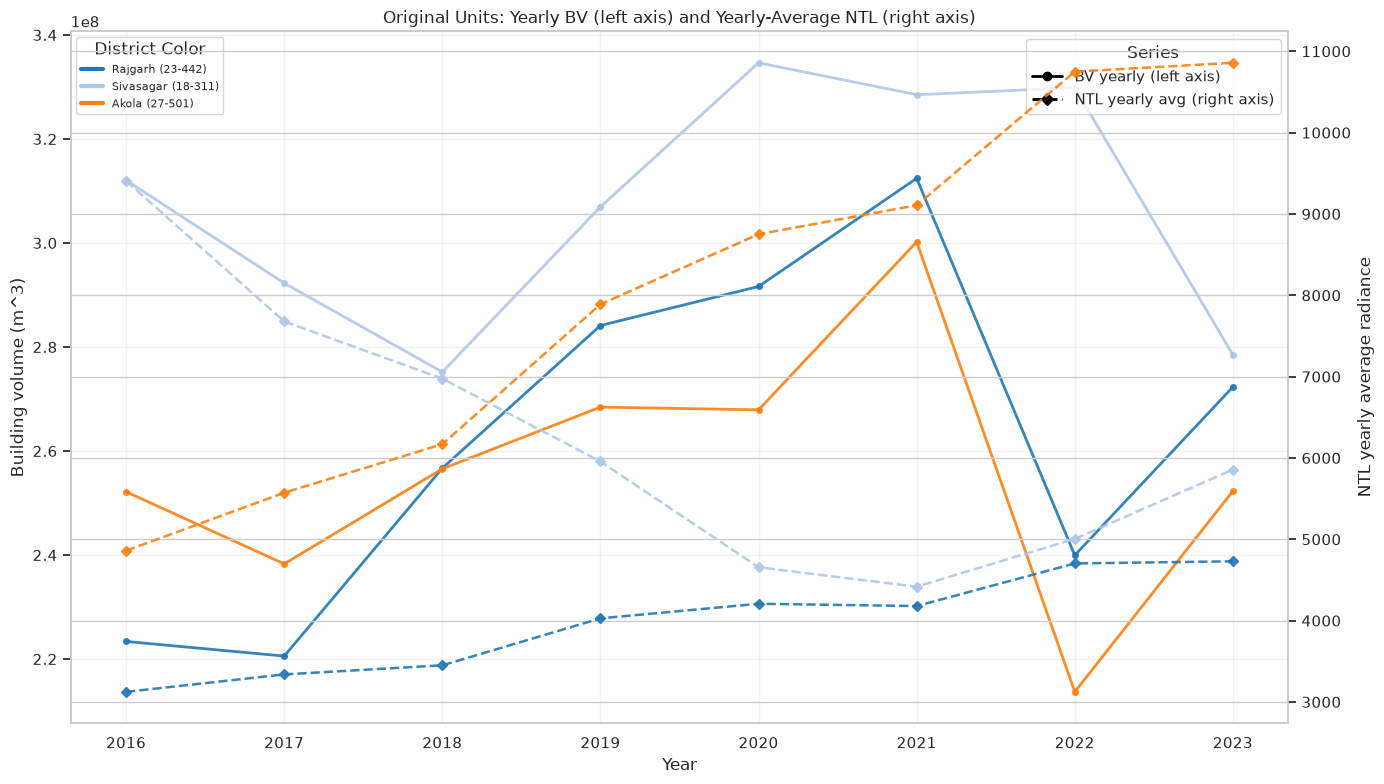

In [49]:
plot_bv_ntl_yearly_avg_original_units(
    *['Rajgarh', 'Sivasagar', 'Akola'],
    strict=False,
    verbose=True,
)

In [ ]:
def plot_bv_ntl_yearly_avg_original_units(
    *districts,
    bv_df: pd.DataFrame | None = None,
    viirs_df: pd.DataFrame | None = None,
    start_year: int | None = None,
    end_year: int | None = None,
    figsize: tuple[int, int] = (13, 7),
    alpha: float = 0.9,
    strict: bool = False,
    verbose: bool = True,
) -> tuple[plt.Figure, tuple[plt.Axes, plt.Axes]]:
    """Plot yearly BV and yearly-average NTL in original units.

    - BV uses left y-axis (m^3, raw values).
    - NTL yearly average uses right y-axis (radiance, raw values).
    - Each district gets one color used for both BV and NTL.
    """
    if len(districts) == 0:
        raise ValueError("Provide at least one district selector.")

    if bv_df is None:
        if "bv" not in globals():
            raise ValueError("No bv_df passed and global bv not found.")
        bv_df = bv.copy()
    else:
        bv_df = bv_df.copy()

    if viirs_df is None:
        if "viirs" not in globals():
            raise ValueError("No viirs_df passed and global viirs not found.")
        viirs_df = viirs.copy()
    else:
        viirs_df = viirs_df.copy()

    volume_col = "building_volume_m3" if "building_volume_m3" in bv_df.columns else "volume_m3"
    if volume_col not in bv_df.columns:
        raise ValueError("Could not find yearly BV column (volume_m3 or building_volume_m3).")

    if "sum_radiance" not in viirs_df.columns:
        raise ValueError("Could not find NTL column sum_radiance.")

    if "date" not in viirs_df.columns:
        if {"year", "month"}.issubset(viirs_df.columns):
            viirs_df["date"] = pd.to_datetime(
                viirs_df["year"].astype(str) + "-" + viirs_df["month"].astype(str) + "-01"
            )
        else:
            raise ValueError("VIIRS data needs either date or both year and month columns.")

    viirs_df["date"] = pd.to_datetime(viirs_df["date"])
    viirs_df["year"] = viirs_df["date"].dt.year.astype(int)
    bv_df["year"] = bv_df["year"].astype(int)

    id_cols = ["pc11_s_id", "pc11_d_id", "d_name"]

    ntl_yearly_avg = (
        viirs_df.groupby(id_cols + ["year"], as_index=False)["sum_radiance"]
        .mean()
        .rename(columns={"sum_radiance": "ntl_avg_radiance"})
    )

    bv_yearly = (
        bv_df.groupby(id_cols + ["year"], as_index=False)[volume_col]
        .sum()
        .rename(columns={volume_col: "building_volume_m3"})
    )

    district_universe = ntl_yearly_avg[id_cols].drop_duplicates().merge(
        bv_yearly[id_cols].drop_duplicates(),
        on=id_cols,
        how="inner",
    )

    selected_rows = []
    seen = set()
    missing = []

    for selector in districts:
        matched = _resolve_district_selector(selector, district_universe)
        if matched.empty:
            missing.append(selector)
            continue
        for _, row in matched.iterrows():
            key = (row["pc11_s_id"], row["pc11_d_id"], row["d_name"])
            if key in seen:
                continue
            seen.add(key)
            selected_rows.append(row.to_dict())

    if missing and strict:
        raise ValueError(f"No district found for selector(s): {missing}")

    if not selected_rows:
        sample = district_universe[["pc11_s_id", "pc11_d_id", "d_name"]].head(10)
        raise ValueError(
            "None of the requested selectors matched. Example available districts:\n"
            + sample.to_string(index=False)
        )

    if missing and verbose:
        print(f"Skipping {len(missing)} unmatched selector(s): {missing}")

    selected = pd.DataFrame(selected_rows)

    yearly = bv_yearly.merge(ntl_yearly_avg, on=id_cols + ["year"], how="inner")
    yearly = yearly.merge(selected, on=id_cols, how="inner")

    if start_year is not None:
        yearly = yearly[yearly["year"] >= int(start_year)]
    if end_year is not None:
        yearly = yearly[yearly["year"] <= int(end_year)]

    if yearly.empty:
        raise ValueError("No yearly data left after district/year filtering.")

    yearly = yearly.sort_values(["pc11_s_id", "pc11_d_id", "year"]).copy()

    district_keys = [tuple(x) for x in selected[id_cols].drop_duplicates().itertuples(index=False, name=None)]
    palette = sns.color_palette("colorblind", n_colors=max(len(district_keys), 3))
    district_colors = {k: palette[i] for i, k in enumerate(district_keys)}

    fig, ax_left = plt.subplots(figsize=figsize)
    ax_right = ax_left.twinx()
    ax_right.grid(False)

    for key, g in yearly.groupby(id_cols):
        color = district_colors[key]

        ax_left.plot(
            g["year"],
            g["building_volume_m3"],
            linestyle="-",
            marker="o",
            markersize=6,
            linewidth=2.2,
            color=color,
            alpha=alpha,
        )

        ax_right.plot(
            g["year"],
            g["ntl_avg_radiance"],
            linestyle="--",
            marker="D",
            markersize=6,
            linewidth=1.8,
            color=color,
            alpha=alpha,
        )

    years_present = sorted(yearly["year"].unique())
    ax_left.set_xticks(years_present)
    ax_left.set_xlabel("Year", fontsize=11)
    ax_left.set_ylabel("Building volume (million m³)", fontsize=11)
    ax_right.set_ylabel("NTL yearly-average radiance", fontsize=11)
    ax_left.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v / 1e6:,.0f}"))
    ax_right.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax_left.grid(True, alpha=0.3)
    sns.despine(ax=ax_left, right=False)
    sns.despine(ax=ax_right, left=True, right=False)

    district_names = ", ".join(
        r.d_name for r in selected[id_cols].drop_duplicates().itertuples(index=False)
    )
    fig.suptitle(f"Building volume vs. nighttime lights — {district_names}", fontsize=14, fontweight="bold")
    ax_left.set_title(
        "Solid = building volume (left axis)   ·   Dashed = NTL yearly average (right axis)",
        fontsize=10, color="#555555", pad=10,
    )

    district_handles = [
        Line2D(
            [0],
            [0],
            color=district_colors[(r.pc11_s_id, r.pc11_d_id, r.d_name)],
            lw=3,
            label=r.d_name,
        )
        for r in selected[id_cols].drop_duplicates().itertuples(index=False)
    ]

    style_handles = [
        Line2D([0], [0], color="0.35", lw=2, linestyle="-", marker="o", label="Building volume"),
        Line2D([0], [0], color="0.35", lw=2, linestyle="--", marker="D", label="NTL yearly avg"),
    ]

    ax_left.legend(
        handles=district_handles + style_handles,
        loc="upper left",
        bbox_to_anchor=(1.08, 1.0),
        frameon=False,
        fontsize=9,
    )

    if verbose:
        plotted = selected[["pc11_s_id", "pc11_d_id", "d_name"]].drop_duplicates()
        print("Plotted districts:")
        print(plotted.to_string(index=False))

    fig.tight_layout(rect=[0, 0, 0.85, 0.96])
    return fig, (ax_left, ax_right)


# Example:
plot_bv_ntl_yearly_avg_original_units(
    *['Rajgarh', 'Sivasagar', 'Akola'],
    start_year="2016",
    end_year="2020",
    strict=False,
    verbose=True,
)

In [ ]:
# Akola ; growth, but sharper ntl 
# rajgarh; growth, even
# sivasagar; growth in bv, but decline in ntl

## Most-stark district per trend type (2016-2021), XKDR house style

One district per `pair_type` bucket from the trend-classification pass above, chosen as the most extreme example of that pattern after excluding districts whose building-volume series has an implausible >2x single-year jump (a data artifact, not a real trend — e.g. Lakshadweep and North District were excluded this way). Styled per `XKDR_DASHBOARD_STYLE.md`: coral + black as the only accent colors, sharp edges, Montserrat headings, serif italic captions, mono uppercase chips for the pattern label.

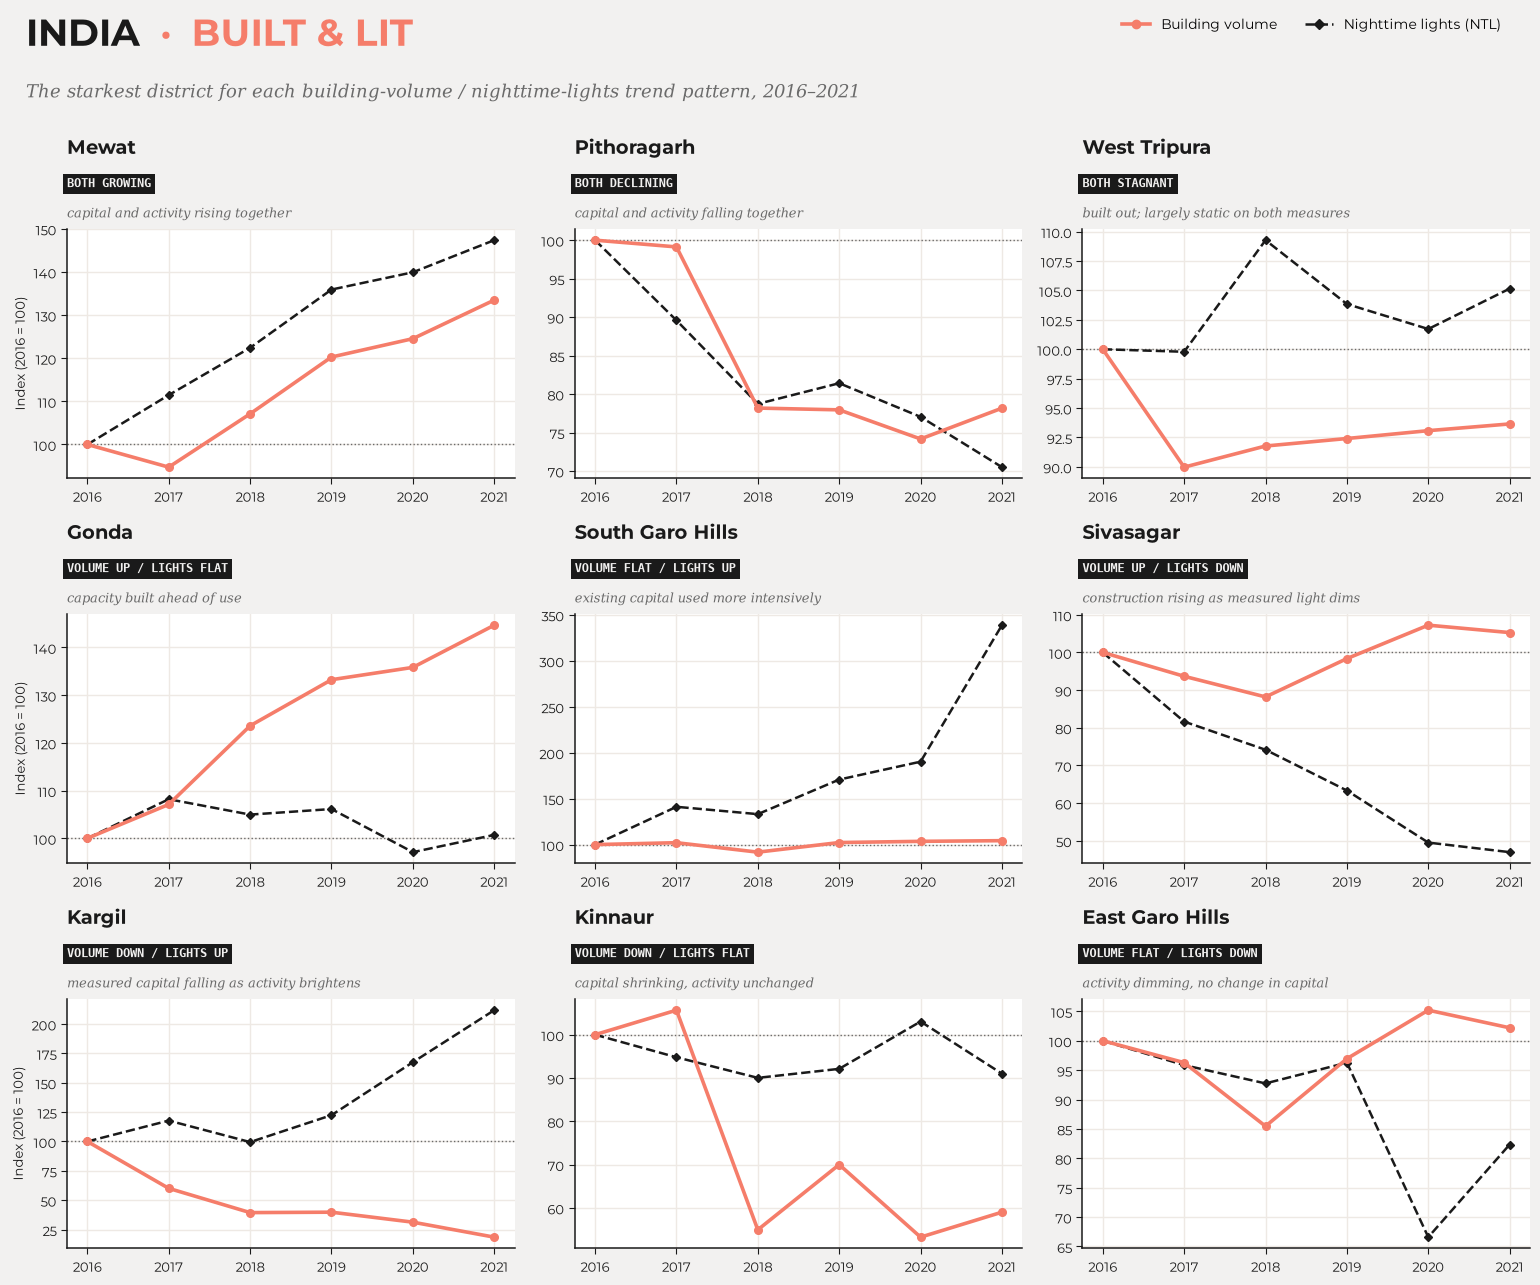

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

# --- XKDR house palette (XKDR_DASHBOARD_STYLE.md) ---
CORAL   = "#f57d6a"
BLACK   = "#1a1a1a"
THEME   = "#f2f1f0"
WHITE   = "#ffffff"
MUTED   = "#6a6a6a"
LINE    = "#e1ddd9"
GRID    = "#eee9e4"

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Montserrat"]

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "blog" / "bv_annual.csv").exists():
            return candidate
    raise FileNotFoundError("repo root not found")

root = find_repo_root(Path.cwd())
bv = pd.read_csv(root / "blog" / "bv_annual.csv")
viirs = pd.read_csv(root / "blog" / "viirs_monthly.csv")
bv["year"] = bv["year"].astype(int)
viirs["year"] = viirs["year"].astype(int)
bv = bv[bv["d_name"].notna() & (bv["d_name"] != "missing")].copy()
viirs = viirs[viirs["d_name"].notna() & (viirs["d_name"] != "missing")].copy()

ntl_yearly = (
    viirs.groupby(["pc11_s_id", "pc11_d_id", "d_name", "year"], as_index=False)["sum_radiance"].sum()
    .rename(columns={"sum_radiance": "ntl_sum_radiance"})
)
merged = bv[["pc11_s_id", "pc11_d_id", "d_name", "year", "volume_m3"]].merge(
    ntl_yearly, on=["pc11_s_id", "pc11_d_id", "d_name", "year"], how="inner"
)
# BV for 2022+ shows an implausible sharp fall rather than the expected monotonic
# increase, so trend comparisons here stop at 2021.
merged = merged[merged["year"].between(2016, 2021)].copy()

# Most-stark district for each agreement/disagreement type identified in the
# trend-classification pass above (annual_slope + classify_pair, 2016-2021),
# hand-picked after excluding districts with an implausible >2x single-year
# jump in building volume (a data-quality artifact, not a real trend).
STARK_DISTRICTS = [
    ("Both growing",                    "capital and activity rising together",            6,  87,  "Mewat"),
    ("Both declining",                  "capital and activity falling together",            5,  62,  "Pithoragarh"),
    ("Both stagnant",                   "built out; largely static on both measures",      16, 289, "West Tripura"),
    ("Volume UP / lights flat",         "capacity built ahead of use",                       9, 183, "Gonda"),
    ("Volume flat / lights UP",         "existing capital used more intensively",           17, 295, "South Garo Hills"),
    ("Volume UP / lights DOWN",         "construction rising as measured light dims",       18, 311, "Sivasagar"),
    ("Volume DOWN / lights UP",         "measured capital falling as activity brightens",    1,   4, "Kargil"),
    ("Volume DOWN / lights flat",       "capital shrinking, activity unchanged",             2,  34, "Kinnaur"),
    ("Volume flat / lights DOWN",       "activity dimming, no change in capital",           17, 294, "East Garo Hills"),
]

fig, axes = plt.subplots(3, 3, figsize=(15.5, 13), facecolor=THEME)

for ax, (pair_label, subtitle, sid, did, name) in zip(axes.ravel(), STARK_DISTRICTS):
    g = merged[(merged["pc11_s_id"] == sid) & (merged["pc11_d_id"] == did)].sort_values("year")

    vol_idx = g["volume_m3"] / g["volume_m3"].iloc[0] * 100
    ntl_idx = g["ntl_sum_radiance"] / g["ntl_sum_radiance"].iloc[0] * 100

    ax.set_facecolor(WHITE)
    ax.plot(g["year"], vol_idx, color=CORAL, lw=2.6, marker="o", markersize=5.5, zorder=3)
    ax.plot(g["year"], ntl_idx, color=BLACK, lw=1.8, linestyle="--", marker="D", markersize=4.5, zorder=2)
    ax.axhline(100, color=MUTED, lw=1, linestyle=":", zorder=1)

    # All three header pieces are anchored with fixed point offsets (not axes-fraction
    # coordinates) so the stacking order survives regardless of each row's rendered
    # axes height; loc="left" keeps long titles from drifting into the chip's corner.
    ax.set_title(name, loc="left", fontsize=14, fontweight="bold", color=BLACK,
                 family="Montserrat", pad=54)
    ax.annotate(
        pair_label.upper(), xy=(0, 1), xycoords="axes fraction",
        xytext=(0, 28), textcoords="offset points",
        fontsize=8.5, fontweight="bold", family="monospace",
        color=THEME, va="bottom", ha="left",
        bbox=dict(boxstyle="square,pad=0.35", facecolor=BLACK, edgecolor="none"),
    )
    ax.annotate(
        subtitle, xy=(0, 1), xycoords="axes fraction",
        xytext=(0, 6), textcoords="offset points",
        fontsize=9.5, style="italic", family="serif", color=MUTED, va="bottom", ha="left",
    )

    ax.set_xticks(sorted(g["year"].unique()))
    ax.grid(True, color=GRID, linewidth=1, zorder=0)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(BLACK)
        ax.spines[side].set_linewidth(1.1)
    ax.tick_params(colors=BLACK, length=4, labelsize=9.5)
    if ax in axes[:, 0]:
        ax.set_ylabel("Index (2016 = 100)", fontsize=9.5, color=BLACK, family="Montserrat")

# Brand mark: "INDIA" in black, dot + "BUILT & LIT" in coral (accent applies only
# to the right half, per XKDR_DASHBOARD_STYLE.md's wordmark rule). Widths are
# measured after each draw so the pieces sit flush next to each other.
TITLE_Y = 0.985
renderer = fig.canvas.get_renderer()
x = 0.02
for text, color, extra_gap in [
    ("INDIA", BLACK, 0.006),
    (" · ", CORAL, 0.006),
    ("BUILT & LIT", CORAL, 0.0),
]:
    t = fig.text(x, TITLE_Y, text, fontsize=27, fontweight="bold", color=color,
                 family="Montserrat", ha="left", va="top")
    fig.canvas.draw()
    bbox = t.get_window_extent(renderer=renderer)
    x = fig.transFigure.inverted().transform((bbox.x1, 0))[0] + extra_gap

fig.text(
    0.02, 0.928, "The starkest district for each building-volume / nighttime-lights trend pattern, 2016–2021",
    fontsize=13, color=MUTED, family="serif", style="italic", ha="left", va="top",
)

legend_handles = [
    Line2D([0], [0], color=CORAL, lw=2.6, marker="o", markersize=6, label="Building volume"),
    Line2D([0], [0], color=BLACK, lw=1.8, linestyle="--", marker="D", markersize=5, label="Nighttime lights (NTL)"),
]
fig.legend(
    handles=legend_handles, loc="upper right", bbox_to_anchor=(0.98, 0.99),
    frameon=False, fontsize=11, prop={"family": "Montserrat"}, ncol=2,
)

fig.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()
